<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/deep_learning/Demo_CNN_Multiclass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Networks (CNN) for Image Classification

## Introduction

Feedforward MLPs treat every input pixel as an independent feature — they have **no notion of spatial structure**. A convolutional neural network (CNN) exploits the **local spatial correlations** present in images:

- **Weight sharing**: the same filter is applied across all spatial locations → far fewer parameters
- **Translation equivariance**: if a feature (e.g., an edge) shifts, the output shifts accordingly
- **Hierarchical feature learning**: low-level filters (edges, blobs) → mid-level (textures) → high-level (object parts)

## Notation

| Symbol | Meaning |
|--------|---------|
| $B$ | Batch size |
| $C_{\text{in}}, C_{\text{out}}$ | Number of input / output channels |
| $H, W$ | Spatial height and width of a feature map |
| $F$ | Filter (kernel) size (square: $F \times F$) |
| $P$ | Padding (number of pixels added to each side) |
| $S$ | Stride (step size of the filter) |
| $K$ | Number of output classes |

## What We Cover

1. Load and explore **Fashion MNIST** (28×28 grayscale, 10 classes)
2. Build a **two-layer CNN** from scratch in PyTorch
3. Train and observe **overfitting**
4. Apply **data augmentation** to mitigate overfitting
5. Add **Dropout regularization** and compare results

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

## Import the Fashion MNIST Dataset

We use [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist), a drop-in replacement for MNIST with 70,000 grayscale images (60K train / 10K test) of 10 clothing categories at 28×28 pixels.

Fashion MNIST is harder than digit MNIST and is a more realistic benchmark for comparing model architectures.

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite" width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

We use 60,000 images for training and 10,000 for evaluation.

In [27]:
# Download and load the training data
trainset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True)
# Download and load the test data
testset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=False)

In [28]:
train_images = trainset.data.numpy()
train_labels = trainset.targets.numpy()

test_images = testset.data.numpy()
test_labels = testset.targets.numpy()

Images are NumPy arrays of shape (28, 28) with pixel values in [0, 255]. Labels are integers in {0, …, 9} corresponding to clothing categories:

<table>
  <tr><th>Label</th><th>Class</th></tr>
  <tr><td>0</td><td>T-shirt/top</td></tr>
  <tr><td>1</td><td>Trouser</td></tr>
  <tr><td>2</td><td>Pullover</td></tr>
  <tr><td>3</td><td>Dress</td></tr>
  <tr><td>4</td><td>Coat</td></tr>
  <tr><td>5</td><td>Sandal</td></tr>
  <tr><td>6</td><td>Shirt</td></tr>
  <tr><td>7</td><td>Sneaker</td></tr>
  <tr><td>8</td><td>Bag</td></tr>
  <tr><td>9</td><td>Ankle boot</td></tr>
</table>

We map numeric labels to their class names for readable output:

In [29]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

## Dataset Exploration

In [30]:
train_images.shape

(60000, 28, 28)

In [31]:
len(train_labels)

60000

Each label is an integer in {0, …, 9}:

In [32]:
np.unique(train_labels)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

Let's also check the test set dimensions:

In [33]:
test_images.shape

(10000, 28, 28)

In [34]:
len(test_labels)

10000

## Pre-processing

Pixel intensities are integers in [0, 255]. We **normalise** them to [0.0, 1.0] by dividing by 255.

**Why normalise?**
- Keeps gradient magnitudes consistent across layers
- Speeds up convergence (all inputs on the same scale)
- Avoids numerical overflow in activations

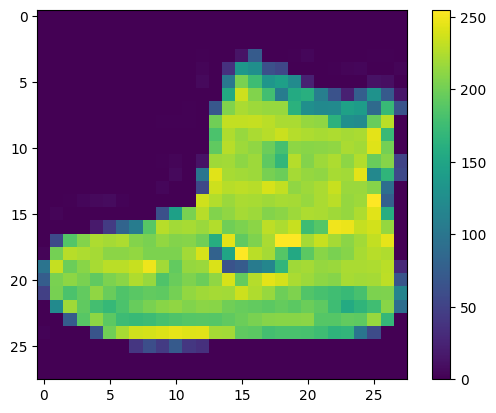

In [35]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

Rescale pixel values to [0, 1]:

In [36]:
train_images = train_images / 255.0
test_images = test_images / 255.0

Sample images from the training set:

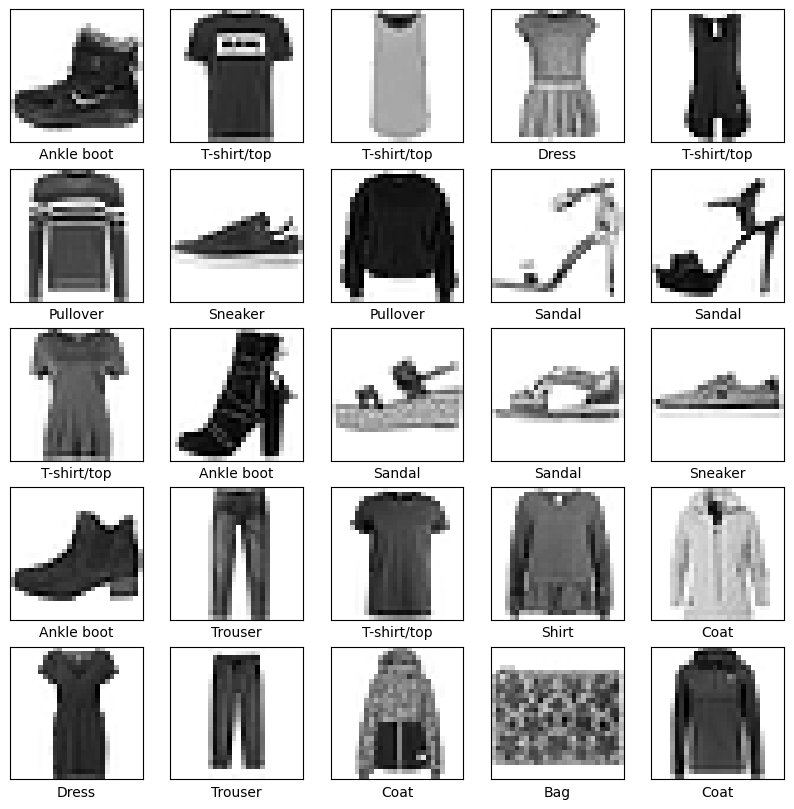

In [37]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

## Preparing DataLoaders

PyTorch's `DataLoader` wraps a `TensorDataset` and handles batching, shuffling, and parallel data loading.

A **batch size** of 64 is a common default: large enough for stable gradient estimates, small enough to fit in GPU memory.

In [38]:
from torch.utils.data import DataLoader, TensorDataset

# Create TensorDatasets
train_dataset = torch.tensor(train_images, dtype=torch.float32)
train_labels = torch.tensor(train_labels, dtype=torch.long)
test_dataset = torch.tensor(test_images, dtype=torch.float32)
test_labels = torch.tensor(test_labels, dtype=torch.long)

# Create TensorDatasets
train_dataset = TensorDataset(train_dataset, train_labels)
test_dataset = TensorDataset(test_dataset, test_labels)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Theory: Convolutional Neural Networks

### 2D Convolution

For a single-channel input $I$ and a filter $K$ of size $F \times F$, the output feature map is:

$$O[i,j] = \sum_{m=0}^{F-1} \sum_{n=0}^{F-1} I[i \cdot S + m,\; j \cdot S + n] \cdot K[m, n] + b$$

**Output spatial size** (with padding $P$, stride $S$):

$$H_{\text{out}} = \left\lfloor \frac{H_{\text{in}} + 2P - F}{S} \right\rfloor + 1$$

For our CNN with $F=3$, $P=1$, $S=1$: $H_{\text{out}} = H_{\text{in}}$ ("same" padding).

### Max Pooling

Max pooling with a $2\times 2$ window and stride 2:

$$O[i,j] = \max_{0 \le m < 2,\; 0 \le n < 2} A[2i+m,\; 2j+n]$$

Each pooling halves the spatial dimensions: $H \to H/2$.

### Spatial Dimension Trace (our network)

| Layer | Output shape |
|-------|-------------|
| Input | $(B, 1, 28, 28)$ |
| Conv1 (8 filters, $3\times 3$, $P=1$) + ReLU | $(B, 8, 28, 28)$ |
| MaxPool $2\times 2$ | $(B, 8, 14, 14)$ |
| Conv2 (16 filters, $3\times 3$, $P=1$) + ReLU | $(B, 16, 14, 14)$ |
| MaxPool $2\times 2$ | $(B, 16, 7, 7)$ |
| Flatten | $(B, 784)$ |
| Linear → log-softmax | $(B, 10)$ |

### Why ReLU?

$\text{ReLU}(z) = \max(0, z)$

- Computationally cheap
- Sparse activations (many exact zeros → efficient)
- Does **not** saturate for positive inputs → mitigates vanishing gradients

### Build the Model

In [39]:
import torch.nn as nn
import torch.nn.functional as F

import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # First convolution: 1 input channel (grayscale), 8 output channels, 3x3 kernel, padding=1 (same padding)
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        # Second convolution: 8 input channels, 16 output channels, 3x3 kernel, padding=1 (same padding)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        # Max pooling with a 2x2 kernel and stride of 2
        self.pool = nn.MaxPool2d(2, 2)
        # Fully connected layers
        self.fc = nn.Linear(16 * 7 * 7, 10)  # Output layer for 10 classes

    def forward(self, x):
        x = x.reshape(-1, 1, 28, 28)  # Input reshaped to (batch_size, 1, 28, 28) for grayscale images
        # After first conv layer: (batch_size, 8, 28, 28)
        x = F.relu(self.conv1(x))
        # After first pooling layer: (batch_size, 8, 14, 14)
        x = self.pool(x)
        # After second conv layer: (batch_size, 16, 14, 14)
        x = F.relu(self.conv2(x))
        # After second pooling layer: (batch_size, 16, 7, 7)
        x = self.pool(x)
        # Flatten the output: (batch_size, 16 * 7 * 7) = (batch_size, 784)
        x = x.view(-1, 16 * 7 * 7)
        # Output layer: (batch_size, 10)
        x = self.fc(x)
        # Apply log softmax for classification output
        return F.log_softmax(x, dim=1)

# Instantiate the model
model = CNN()

### Model Summary

`torchsummary` prints each layer's output shape and parameter count, making it easy to verify the spatial dimension trace above.

Note: total parameters ≈ 16 × 7 × 7 × 1 (bias in fc) + 16 × 7 × 7 × 10 (fc weights) + conv params.

In [40]:
from torchsummary import summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 28, 28]              80
         MaxPool2d-2            [-1, 8, 14, 14]               0
            Conv2d-3           [-1, 16, 14, 14]           1,168
         MaxPool2d-4             [-1, 16, 7, 7]               0
            Linear-5                   [-1, 10]           7,850
Total params: 9,098
Trainable params: 9,098
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.09
Params size (MB): 0.03
Estimated Total Size (MB): 0.13
----------------------------------------------------------------


## Define Loss, Optimizer, and Metrics

**Loss — Negative Log-Likelihood (`NLLLoss`):**

Used together with `log_softmax` in the forward pass, which is mathematically equivalent to **categorical cross-entropy**:

$$\mathcal{L} = -\frac{1}{B} \sum_{i=1}^{B} \log \hat{p}_{y_i}^{(i)}$$

where $\hat{p}_{y_i}^{(i)}$ is the predicted probability for the true class $y_i$.

**Optimizer — Adam:** adapts the learning rate per parameter using first and second moment estimates. A learning rate of 0.005 is used here.

In [41]:
criterion = nn.NLLLoss() # loss = -1/N * sum(target_i * log(predicted_prob_i)) predefinido en pytorch.
optimizer = optim.Adam(model.parameters(), lr=0.005)

In [42]:
def accuracy(output, target):
  _, predicted = torch.max(output.data, 1)
  correct = (predicted == target).sum().item()
  accuracy = correct / target.size(0)
  return accuracy

## Train the Model

The standard PyTorch training loop:

1. For each mini-batch: `optimizer.zero_grad()` → forward pass → compute loss → `loss.backward()` → `optimizer.step()`
2. Track loss and accuracy per epoch on both train and test sets
3. Plot learning curves to diagnose underfitting/overfitting

In [43]:
# Training loop with logging and plotting
epochs = 20
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for e in range(epochs):
  running_loss = 0
  running_accuracy = 0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    output = model(images)
    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
    running_accuracy += accuracy(output, labels)

  epoch_loss = running_loss / len(train_loader)
  epoch_accuracy = running_accuracy / len(train_loader)
  train_losses.append(epoch_loss)
  train_accuracies.append(epoch_accuracy)

  # Evaluate on the test set
  running_test_loss = 0
  running_test_accuracy = 0
  with torch.no_grad():  # Disable gradient calculation for evaluation
    for images, labels in test_loader:
      images, labels = images.to(device), labels.to(device)
      output = model(images)
      loss = criterion(output, labels)
      running_test_loss += loss.item()
      running_test_accuracy += accuracy(output, labels)

  epoch_test_loss = running_test_loss / len(test_loader)
  epoch_test_accuracy = running_test_accuracy / len(test_loader)
  test_losses.append(epoch_test_loss)
  test_accuracies.append(epoch_test_accuracy)

  print(f"Epoch {e+1}/{epochs}:")
  print(f"  Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_accuracy:.4f}")
  print(f"  Test Loss: {epoch_test_loss:.4f}, Test Accuracy: {epoch_test_accuracy:.4f}")

Epoch 1/20:
  Train Loss: 0.4498, Train Accuracy: 0.8371
  Test Loss: 0.3746, Test Accuracy: 0.8670
Epoch 2/20:
  Train Loss: 0.3191, Train Accuracy: 0.8851
  Test Loss: 0.3393, Test Accuracy: 0.8773
Epoch 3/20:
  Train Loss: 0.2874, Train Accuracy: 0.8965
  Test Loss: 0.3099, Test Accuracy: 0.8882
Epoch 4/20:
  Train Loss: 0.2683, Train Accuracy: 0.9032
  Test Loss: 0.3039, Test Accuracy: 0.8934
Epoch 5/20:
  Train Loss: 0.2564, Train Accuracy: 0.9068
  Test Loss: 0.2926, Test Accuracy: 0.8983
Epoch 6/20:
  Train Loss: 0.2467, Train Accuracy: 0.9097
  Test Loss: 0.3029, Test Accuracy: 0.8891
Epoch 7/20:
  Train Loss: 0.2422, Train Accuracy: 0.9112
  Test Loss: 0.3037, Test Accuracy: 0.8899
Epoch 8/20:
  Train Loss: 0.2347, Train Accuracy: 0.9160
  Test Loss: 0.3029, Test Accuracy: 0.8938
Epoch 9/20:
  Train Loss: 0.2288, Train Accuracy: 0.9171
  Test Loss: 0.2961, Test Accuracy: 0.8938
Epoch 10/20:
  Train Loss: 0.2223, Train Accuracy: 0.9193
  Test Loss: 0.2915, Test Accuracy: 0.8982

### Learning Curves

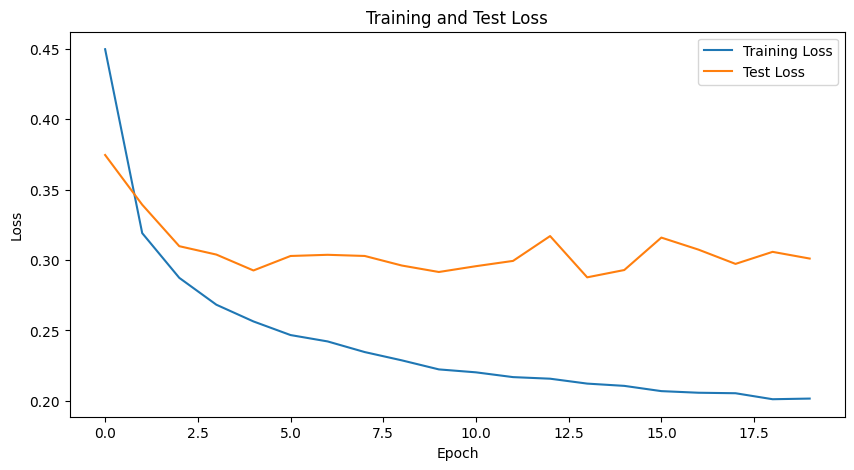

In [44]:
# Plot the training and test losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.show()

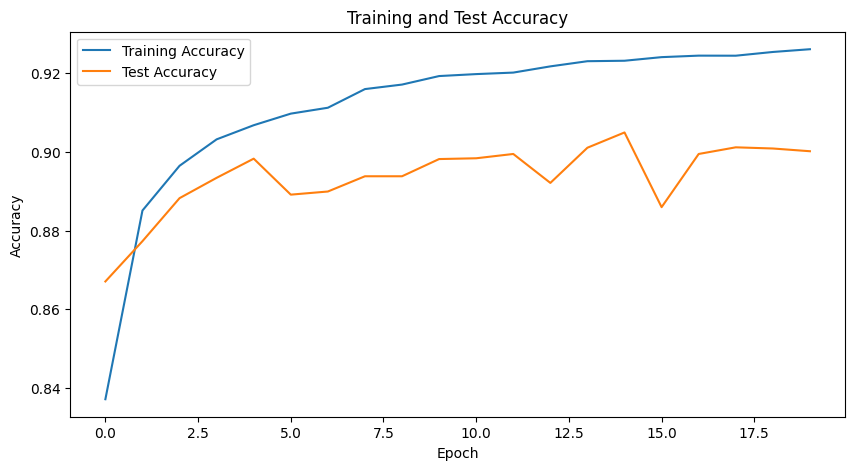

In [45]:
# Plot the training and test accuracies
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()
plt.show()

## Overfitting and Regularization

The plot above shows **overfitting**: training accuracy is significantly higher than test accuracy. This means the model has memorised training patterns that do not generalise.

### Two remedies we will apply:

1. **Data Augmentation** — Increase the effective training set size by applying random transformations
2. **Dropout** — Randomly zero activations during training to prevent co-adaptation of neurons

---

## Data Augmentation

Data augmentation applies stochastic transforms to each image at training time, so the model rarely sees the exact same input twice.

**Random Horizontal Flip:** with probability 0.5, mirrors the image horizontally. For fashion items this is a valid augmentation (a flipped sneaker is still a sneaker).

In [46]:
from torchvision import transforms

# Define data augmentations
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
])

# Download and load the training data with augmentations
trainset_aug = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=train_transforms)
# Download and load the test data with augmentations
testset_aug = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=False, transform=test_transforms)

# Create DataLoaders with augmented data
train_loader_aug = DataLoader(trainset_aug, batch_size=64, shuffle=True)
test_loader_aug = DataLoader(testset_aug, batch_size=64, shuffle=False)

Visualise the effect of the augmentation on a single image:

Original Image:


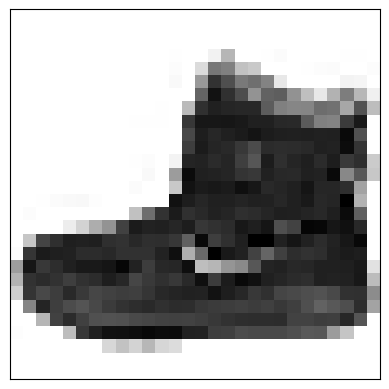


Augmented Images:


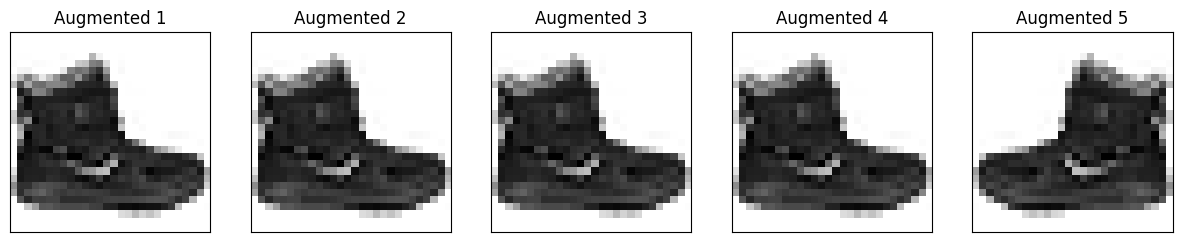

In [47]:
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

def plot_augmented_images(image, augmentation_only_transforms, num_examples=5):
    fig, axes = plt.subplots(1, num_examples, figsize=(15, 3))
    for i in range(num_examples):
        # Apply the augmentation transforms
        augmented_image = augmentation_only_transforms(image)
        # Convert to tensor for visualization
        axes[i].imshow(transforms.ToTensor()(augmented_image).squeeze().numpy(), cmap=plt.cm.binary)
        axes[i].set_xticks([])
        axes[i].set_yticks([])
        axes[i].set_title(f"Augmented {i+1}")
    plt.show()

# Get one image from the training set (before ToTensor and Normalize)
sample_image, sample_label = trainset[0]

# Define augmentation transforms (excluding ToTensor and Normalize for visualization)
augmentation_only_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
])

print("Original Image:")
plt.imshow(transforms.ToTensor()(sample_image).squeeze().numpy(), cmap=plt.cm.binary)
plt.xticks([])
plt.yticks([])
plt.show()

print("\nAugmented Images:")
plot_augmented_images(sample_image, augmentation_only_transforms)


Each epoch presents a differently augmented version of the image, effectively expanding the dataset. This encourages the model to learn **invariant features** rather than memorising exact pixel patterns.

---

## Dropout Regularization

During training, dropout randomly sets each neuron's activation to zero with probability $p$:

$$\tilde{h}_i = \frac{h_i \cdot \mathbf{1}[B_i > p]}{1 - p}, \quad B_i \sim \text{Uniform}[0,1]$$

The $1/(1-p)$ scaling keeps the expected activation magnitude unchanged at test time (when dropout is **off**).

**Effect:** neurons cannot rely on specific co-activated partners → the network learns redundant, more robust representations.

We add dropout after the flatten layer and re-train with augmented data:

In [48]:
import torch.nn as nn
import torch.nn.functional as F

import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # First convolution: 1 input channel (grayscale), 8 output channels, 3x3 kernel, padding=1 (same padding)
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        # Second convolution: 8 input channels, 16 output channels, 3x3 kernel, padding=1 (same padding)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        # Max pooling with a 2x2 kernel and stride of 2
        self.pool = nn.MaxPool2d(2, 2)
        # Fully connected layers
        self.fc = nn.Linear(16 * 7 * 7, 10)  # Output layer for 10 classes
        self.dropout = nn.Dropout(0.1)  # Dropout layer with a probability of 0.1

    def forward(self, x):
        x = x.reshape(-1, 1, 28, 28)  # Input reshaped to (batch_size, 1, 28, 28) for grayscale images
        # After first conv layer: (batch_size, 8, 28, 28)
        x = F.relu(self.conv1(x))
        # After first pooling layer: (batch_size, 8, 14, 14)
        x = self.pool(x)
        # After second conv layer: (batch_size, 16, 14, 14)
        x = F.relu(self.conv2(x))
        # After second pooling layer: (batch_size, 16, 7, 7)
        x = self.pool(x)
        # Flatten the output: (batch_size, 16 * 7 * 7) = (batch_size, 784)
        x = x.view(-1, 16 * 7 * 7)
        # Apply the dropout
        x = self.dropout(x)
        # Output layer: (batch_size, 10)
        x = self.fc(x)
        # Apply log softmax for classification output
        return F.log_softmax(x, dim=1)

In [24]:
# Re-instantiate the model
model_aug = CNN()
model_aug = model_aug.to(device)

# Define criterion and optimizer for the new model
criterion_aug = nn.NLLLoss()
optimizer_aug = optim.Adam(model_aug.parameters(), lr=0.005)

# Training loop with logging and plotting for augmented data
epochs = 20
train_losses_aug = []
train_accuracies_aug = []
test_losses_aug = []
test_accuracies_aug = []

for e in range(epochs):
    running_loss = 0
    running_accuracy = 0
    for images, labels in train_loader_aug:
        images, labels = images.to(device), labels.to(device)
        optimizer_aug.zero_grad()
        output = model_aug(images)
        loss = criterion_aug(output, labels)
        loss.backward()
        optimizer_aug.step()
        running_loss += loss.item()
        running_accuracy += accuracy(output, labels)

    epoch_loss = running_loss / len(train_loader_aug)
    epoch_accuracy = running_accuracy / len(train_loader_aug)
    train_losses_aug.append(epoch_loss)
    train_accuracies_aug.append(epoch_accuracy)

    # Evaluate on the test set
    running_test_loss = 0
    running_test_accuracy = 0
    with torch.no_grad():
        for images, labels in test_loader_aug:
            images, labels = images.to(device), labels.to(device)
            output = model_aug(images)
            loss = criterion_aug(output, labels)
            running_test_loss += loss.item()
            running_test_accuracy += accuracy(output, labels)

    epoch_test_loss = running_test_loss / len(test_loader_aug)
    epoch_test_accuracy = running_test_accuracy / len(test_loader_aug)
    test_losses_aug.append(epoch_test_loss)
    test_accuracies_aug.append(epoch_test_accuracy)

    print(f"Epoch {e+1}/{epochs}:")
    print(f"  Train Loss (Augmented): {epoch_loss:.4f}, Train Accuracy (Augmented): {epoch_accuracy:.4f}")
    print(f"  Test Loss (Augmented): {epoch_test_loss:.4f}, Test Accuracy (Augmented): {epoch_test_accuracy:.4f}")

Epoch 1/20:
  Train Loss (Augmented): 0.4832, Train Accuracy (Augmented): 0.8286
  Test Loss (Augmented): 0.3757, Test Accuracy (Augmented): 0.8646
Epoch 2/20:
  Train Loss (Augmented): 0.3497, Train Accuracy (Augmented): 0.8747
  Test Loss (Augmented): 0.3643, Test Accuracy (Augmented): 0.8726
Epoch 3/20:
  Train Loss (Augmented): 0.3281, Train Accuracy (Augmented): 0.8827
  Test Loss (Augmented): 0.3479, Test Accuracy (Augmented): 0.8743
Epoch 4/20:
  Train Loss (Augmented): 0.3087, Train Accuracy (Augmented): 0.8896
  Test Loss (Augmented): 0.3392, Test Accuracy (Augmented): 0.8768
Epoch 5/20:
  Train Loss (Augmented): 0.3012, Train Accuracy (Augmented): 0.8909
  Test Loss (Augmented): 0.3314, Test Accuracy (Augmented): 0.8807
Epoch 6/20:
  Train Loss (Augmented): 0.2970, Train Accuracy (Augmented): 0.8925
  Test Loss (Augmented): 0.3288, Test Accuracy (Augmented): 0.8818
Epoch 7/20:
  Train Loss (Augmented): 0.2935, Train Accuracy (Augmented): 0.8924
  Test Loss (Augmented): 0.3103

### Learning Curves with Augmentation + Dropout

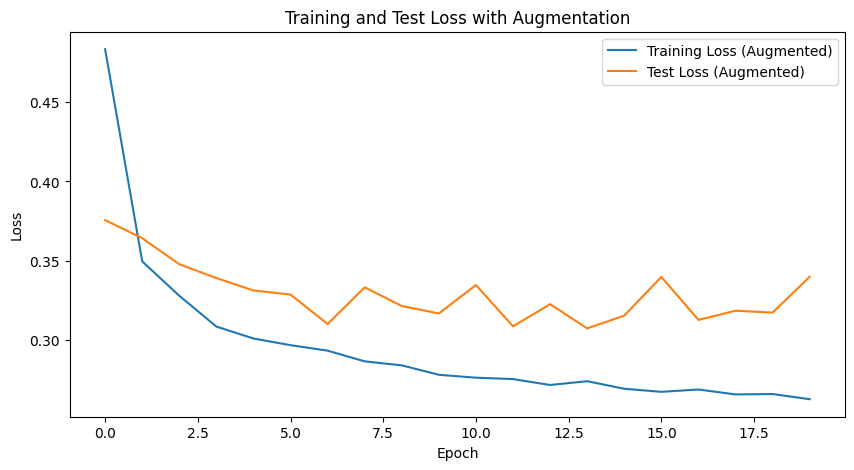

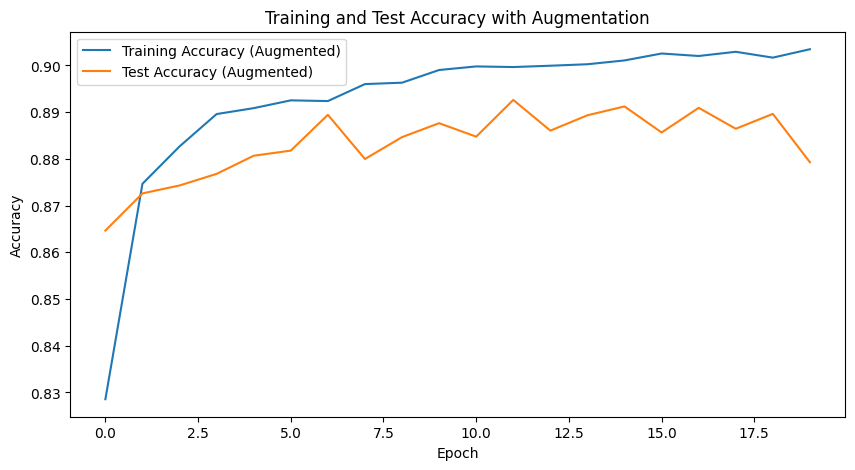

In [25]:
# Plot the training and test losses with augmentation
plt.figure(figsize=(10, 5))
plt.plot(train_losses_aug, label="Training Loss (Augmented)")
plt.plot(test_losses_aug, label="Test Loss (Augmented)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss with Augmentation")
plt.legend()
plt.show()

# Plot the training and test accuracies with augmentation
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies_aug, label="Training Accuracy (Augmented)")
plt.plot(test_accuracies_aug, label="Test Accuracy (Augmented)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy with Augmentation")
plt.legend()
plt.show()

## Reflection Questions

1. **Receptive field.** The receptive field of a neuron is the region of the input image it can "see". After the first conv layer the receptive field is $3\times 3$. After the second conv layer (applied to the already-downsampled feature map), what is the effective receptive field in the original input? In general, how does stacking conv layers grow the receptive field?

2. **Translation invariance vs equivariance.** Convolution is *equivariant* to translation (shifting input shifts output). Max pooling introduces *invariance*. Why is invariance desirable for classification but not for localisation tasks (e.g., eye detection)?

3. **Parameter count.** Count the learnable parameters in this CNN manually:
   - Conv1: $(3 \times 3 \times 1 + 1) \times 8$
   - Conv2: $(3 \times 3 \times 8 + 1) \times 16$
   - FC: $(16 \times 7 \times 7 + 1) \times 10$
   Verify your answer against `torchsummary`.

4. **Dropout and inference.** Why must dropout be **disabled** during inference? What would happen to the output distribution if dropout were left on at test time?

## Answers

**1. Receptive field.**
After Conv1: $3\times3$. After MaxPool1: each output pixel corresponds to a $6\times6$ region of the input. After Conv2: $6+2=8\times8$ (the $3\times3$ filter now covers a region already spanning 6 input pixels). After MaxPool2: $16\times16$. In general, receptive field grows as $R_l = R_{l-1} + (F-1) \cdot \prod_{i<l} S_i$.

**2. Translation invariance vs equivariance.**
Classification needs *invariance*: a shirt is a shirt wherever it appears. Localisation needs *equivariance*: if the eye moves 5 pixels right, the predicted coordinate should also move 5 pixels right. Fully invariant pooling destroys spatial information needed for localisation.

**3. Parameter count.**
- Conv1: $(9 \times 1 + 1) \times 8 = 80$
- Conv2: $(9 \times 8 + 1) \times 16 = 1168$
- FC: $(784 + 1) \times 10 = 7850$
- Total: **9,098**

**4. Dropout and inference.**
With dropout on at inference, the model randomly zeros neurons, producing stochastic (noisy) predictions. The model was trained with the $1/(1-p)$ rescaling assumption to make expected activations equal — but each random draw violates this expectation. Disabling dropout ensures **deterministic, calibrated** output probabilities.